(55, 3)
[ 2  4 11 26 30 32 33 40 43 45 46]
SVR:0.943,0.86,0.274,0.439,0.196,0.544,0.443,0.738


D:\anaconda\Lib\site-packages\seaborn\axisgrid.py:1883: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=self.x, ax=self.ax_marg_x, **kwargs)
D:\anaconda\Lib\site-packages\seaborn\axisgrid.py:1889: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(y=self.y, ax=self.ax_marg_y, **kwargs)


已保存：svr_kfold_plots\fold_01.png


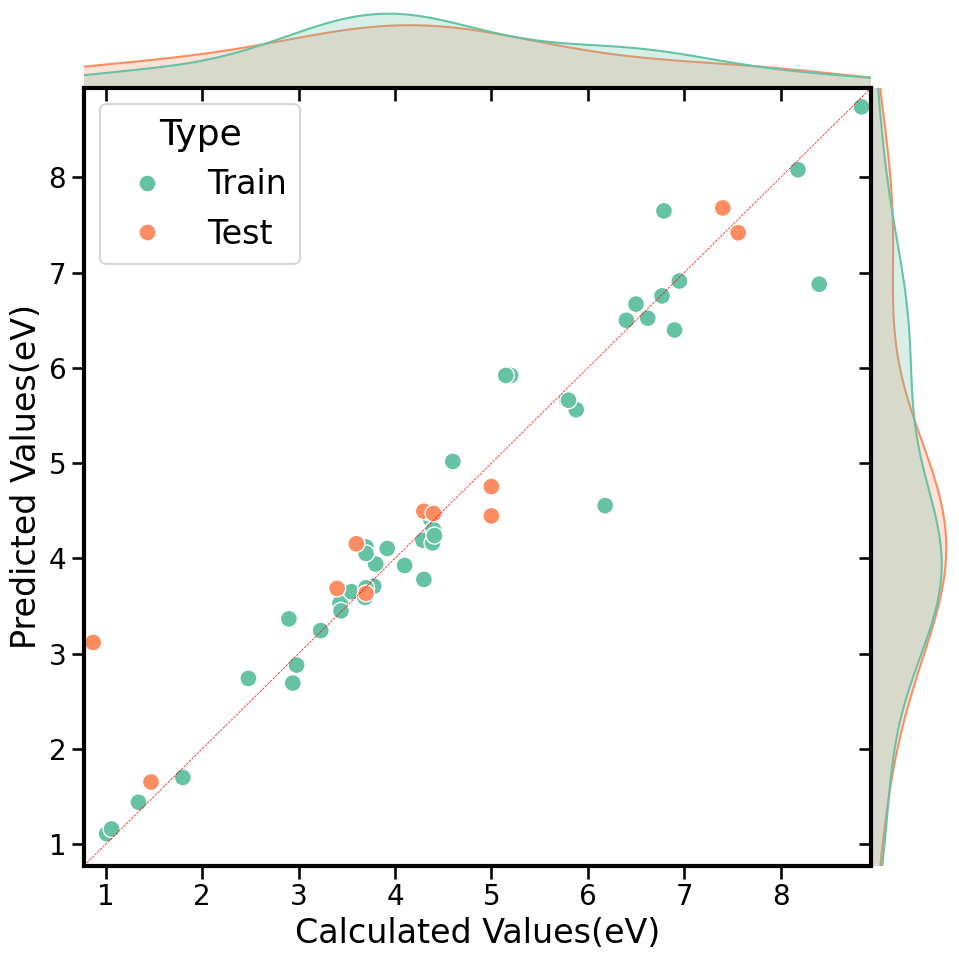

[ 7 10 14 22 27 28 31 35 37 49 50]
SVR:0.965,0.793,0.237,0.424,0.138,0.344,0.371,0.587


D:\anaconda\Lib\site-packages\seaborn\axisgrid.py:1883: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=self.x, ax=self.ax_marg_x, **kwargs)
D:\anaconda\Lib\site-packages\seaborn\axisgrid.py:1889: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(y=self.y, ax=self.ax_marg_y, **kwargs)


已保存：svr_kfold_plots\fold_02.png


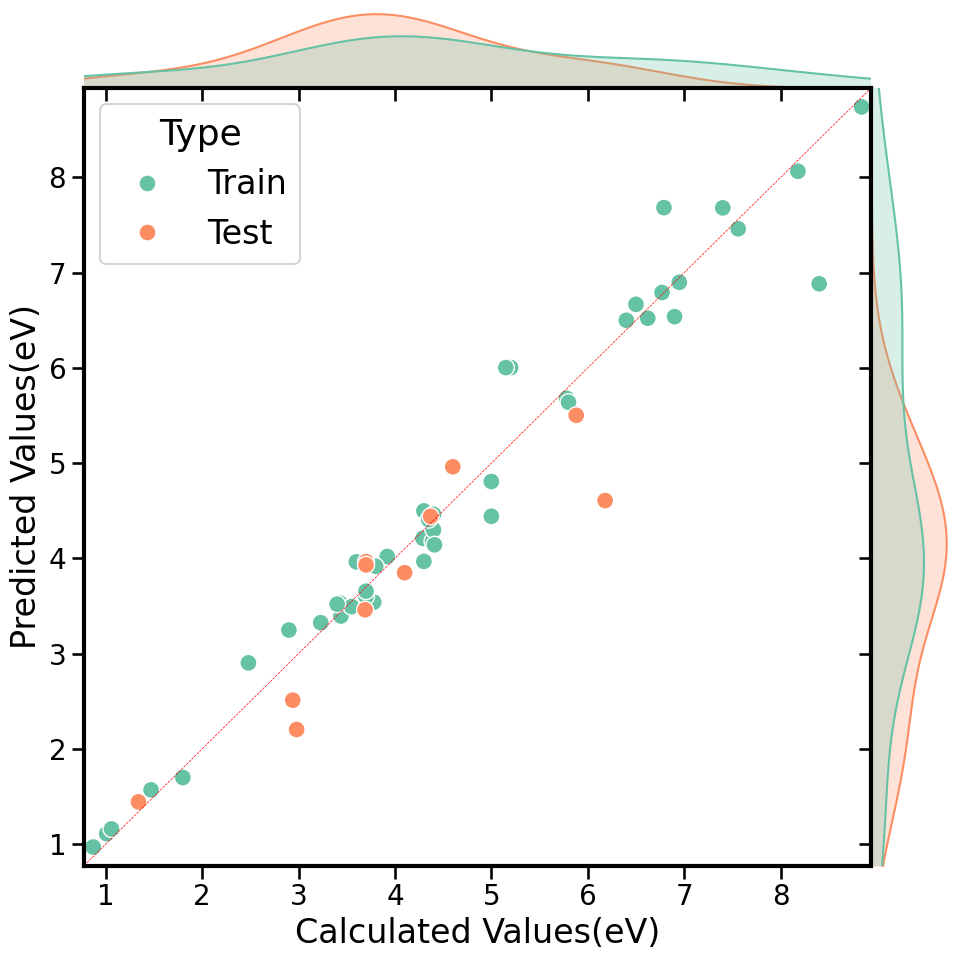

[ 5  8 15 16 18 20 29 34 48 52 53]
SVR:0.943,0.958,0.274,0.291,0.209,0.132,0.457,0.363


D:\anaconda\Lib\site-packages\seaborn\axisgrid.py:1883: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=self.x, ax=self.ax_marg_x, **kwargs)
D:\anaconda\Lib\site-packages\seaborn\axisgrid.py:1889: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(y=self.y, ax=self.ax_marg_y, **kwargs)


已保存：svr_kfold_plots\fold_03.png


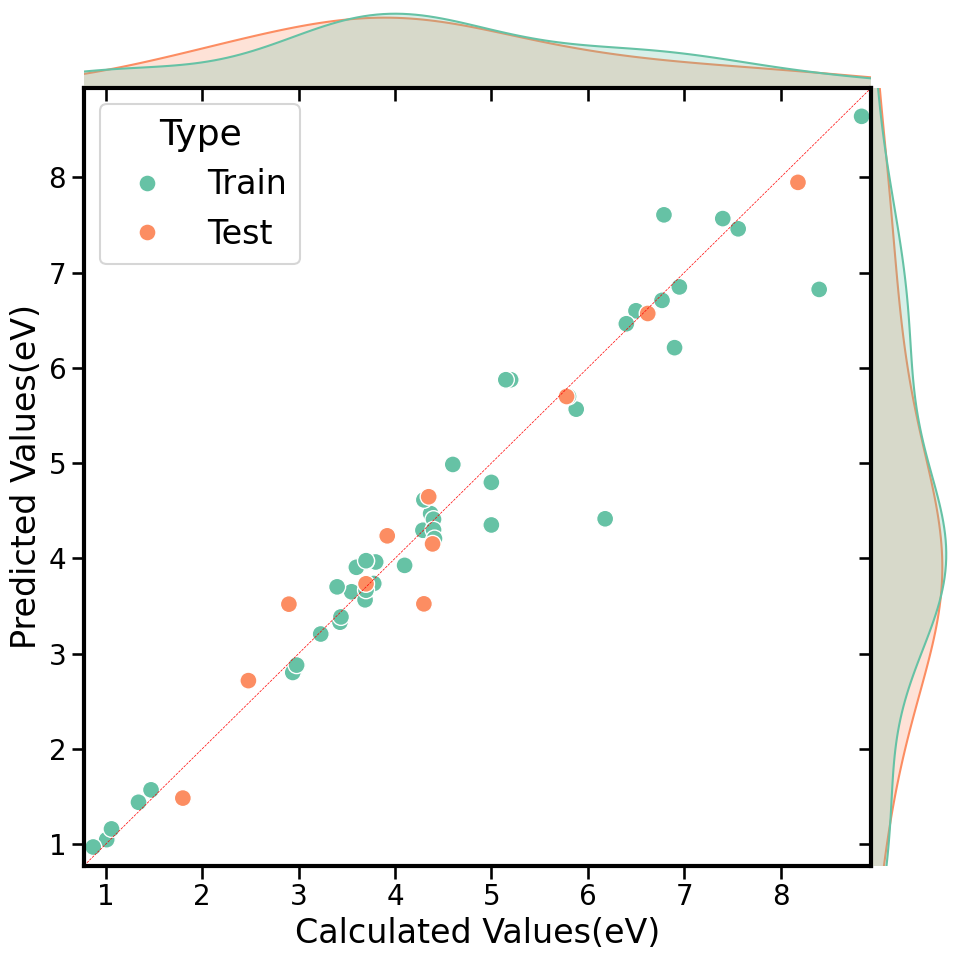

[ 1  6 12 13 17 24 25 38 41 42 54]
SVR:0.957,0.909,0.246,0.419,0.152,0.337,0.39,0.581


D:\anaconda\Lib\site-packages\seaborn\axisgrid.py:1883: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=self.x, ax=self.ax_marg_x, **kwargs)
D:\anaconda\Lib\site-packages\seaborn\axisgrid.py:1889: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(y=self.y, ax=self.ax_marg_y, **kwargs)


已保存：svr_kfold_plots\fold_04.png


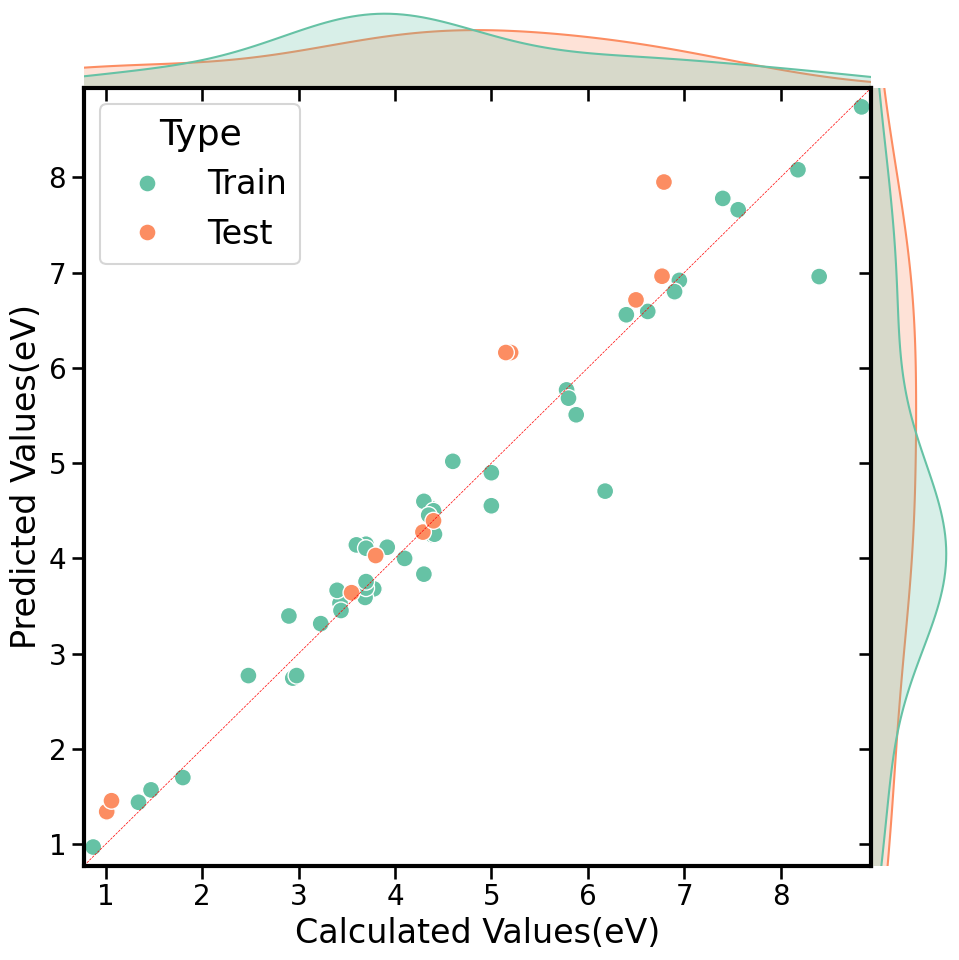

[ 0  3  9 19 21 23 36 39 44 47 51]
SVR:0.951,0.909,0.262,0.399,0.152,0.348,0.39,0.59


D:\anaconda\Lib\site-packages\seaborn\axisgrid.py:1883: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=self.x, ax=self.ax_marg_x, **kwargs)
D:\anaconda\Lib\site-packages\seaborn\axisgrid.py:1889: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(y=self.y, ax=self.ax_marg_y, **kwargs)


已保存：svr_kfold_plots\fold_05.png


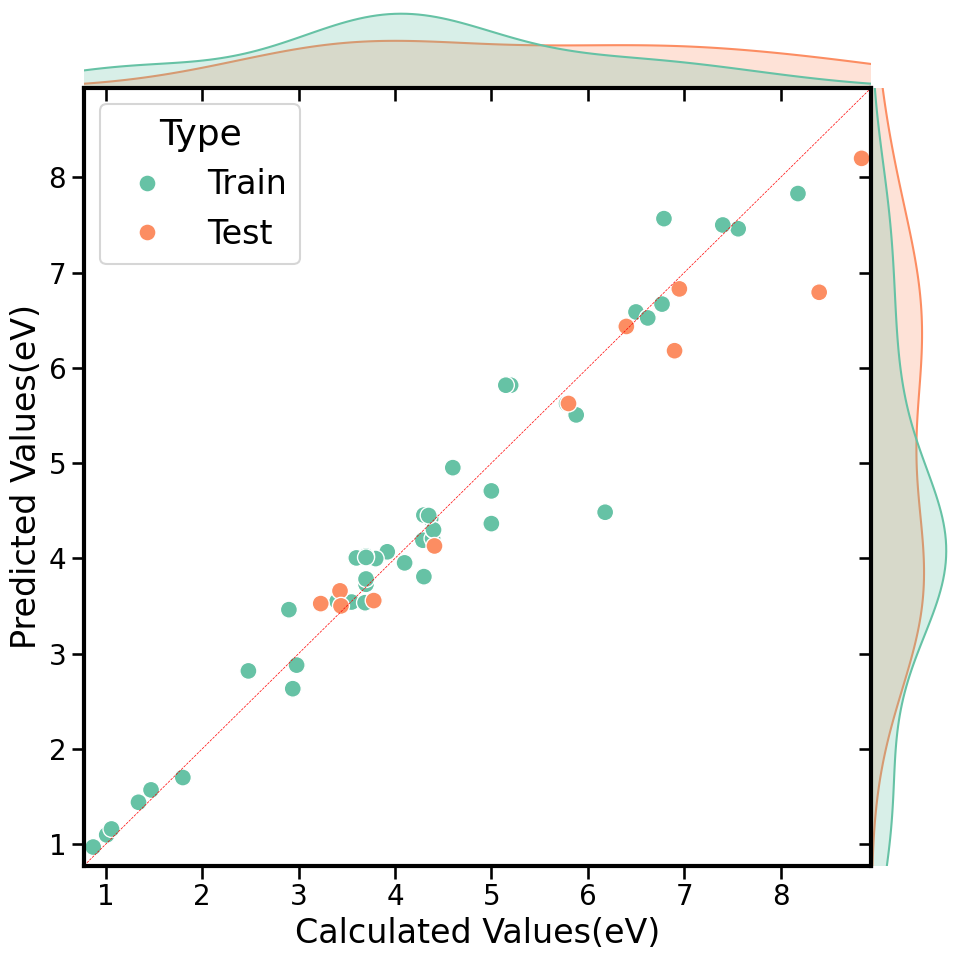

SVR:0.952+-0.008,0.886+-0.056,0.259+-0.015,0.394+-0.053,0.169+-0.028,0.341+-0.13,0.41+-0.034,0.572+-0.12,6.562+-0.0,6.539+-0.0


['model.svr']

In [1]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedKFold
from sklearn.feature_selection import SelectKBest
from scipy.stats import pearsonr
from modules import *
from sklearn.svm import SVR
import sys
import math
import joblib
import numpy as np
import matplotlib.pyplot as plt
import modules
from sklearn.metrics import mean_absolute_percentage_error

File = '../data.4/co-wt'
X,y=sub_data(File)
X,y= pre_data(X,y)
X=np.delete(X,[0,3,4,5],axis=1)
X=X[:55,:]
y=y[:55]

print(X.shape)

import os
# 创建专用保存目录
save_dir = "svr_kfold_plots"
os.makedirs(save_dir, exist_ok=True)


R2_train_a=[]
R2_test_a=[]
MAE_train_a=[]
MAE_test_a=[]
MSE_train_a=[]
MSE_test_a=[]
RMSE_train_a=[]
RMSE_test_a=[]
MAPE_train_a=[]
MAPE_test_a=[]

ns=5
nr=1
kf = RepeatedKFold(n_splits=ns, n_repeats=nr, random_state=0)
for fold_num, (train_index, test_index) in enumerate(kf.split(X), 1):
  X_train, y_train = X[train_index], y[train_index]
  X_test, y_test = X[test_index], y[test_index]
  print(test_index)
 
  svr_rbf = SVR(kernel="rbf", C=10, gamma=0.05, epsilon=0.1)
  svr_rbf.fit(X_train, y_train)
 
  y_pre1=svr_rbf.predict(X_train)
  y_pre2=svr_rbf.predict(X_test)
    
  R2_train=round(svr_rbf.score(X_train, y_train),3)
  R2_test=round(svr_rbf.score(X_test, y_test),3)
  MAE_train = round(mean_absolute_error(y_train,y_pre1),3)
  MAE_test =  round(mean_absolute_error(y_test,y_pre2),3)
  MSE_train = round(mean_squared_error(y_train,y_pre1),3)
  MSE_test = round(mean_squared_error(y_test,y_pre2),3)
  RMSE_train = round(math.sqrt(MSE_train),3)
  RMSE_test = round(math.sqrt(MSE_test),3)
  MAPE_train = round(mean_absolute_percentage_error(y_train, y_pre1) * 100, 3)
  MAPE_test= round(mean_absolute_percentage_error(y_test, y_pre2) * 100, 3)

  R2_train_a += [R2_train]
  R2_test_a += [R2_test]
  MAE_train_a += [MAE_train]
  MAE_test_a += [MAE_test]
  MSE_train_a += [MSE_train]
  MSE_test_a += [MSE_test]
  RMSE_train_a += [RMSE_train]
  RMSE_test_a += [RMSE_test]
  MAPE_train_a=[MAPE_train]
  MAPE_test_a=[MAPE_test]

  print("SVR:%s,%s,%s,%s,%s,%s,%s,%s" %(R2_train,R2_test,MAE_train,MAE_test,MSE_train,MSE_test,RMSE_train,RMSE_test))
  plot_train_test_results1( y_train, y_test, y_pre1, y_pre2, fname=f"fold_{fold_num:02d}", output=True,plt_prop=True,save_dir=save_dir )
  # plot_train_test_results(y_train,y_test,y_pre1,y_pre2)
    
R2_train_mean=round(np.mean(R2_train_a),3)
R2_train_std=round(np.std(R2_train_a),3)
R2_test_mean=round(np.mean(R2_test_a),3)
R2_test_std=round(np.std(R2_test_a),3)
MAE_train_mean=round(np.mean(MAE_train_a),3)
MAE_train_std=round(np.std(MAE_train_a),3)
MAE_test_mean=round(np.mean(MAE_test_a),3)
MAE_test_std=round(np.std(MAE_test_a),3)
MSE_train_mean=round(np.mean(MSE_train_a),3)
MSE_train_std=round(np.std(MSE_train_a),3)
MSE_test_mean=round(np.mean(MSE_test_a),3)
MSE_test_std=round(np.std(MSE_test_a),3)
RMSE_train_mean=round(np.mean(RMSE_train_a),3)
RMSE_train_std=round(np.std(RMSE_train_a),3)
RMSE_test_mean=round(np.mean(RMSE_test_a),3)
RMSE_test_std=round(np.std(RMSE_test_a),3)
MAPE_train_mean=round(np.mean(MAPE_train_a),3)
MAPE_train_std=round(np.std(MAPE_train_a),3)
MAPE_test_mean=round(np.mean(MAPE_test_a),3)
MAPE_test_std=round(np.std(MAPE_test_a),3)  
print("SVR:%s+-%s,%s+-%s,%s+-%s,%s+-%s,%s+-%s,%s+-%s,%s+-%s,%s+-%s,%s+-%s,%s+-%s" %(R2_train_mean,R2_train_std,R2_test_mean,R2_test_std,MAE_train_mean,MAE_train_std,MAE_test_mean,MAE_test_std,MSE_train_mean,MSE_train_std,MSE_test_mean,MSE_test_std,RMSE_train_mean,RMSE_train_std,RMSE_test_mean,RMSE_test_std,MAPE_train_mean,MAPE_train_std,MAPE_test_mean,MAPE_test_std))
#plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=1,
                       # train_sizes=np.linspace(0.05, 1.0, 20), verbose=0, plot=True):
#plot_learning_curve(SVR(),SVR,X,y,n_jobs=1,train_sizes=np.linspace(0.05, 1.0, 20), verbose=0, plot=True)
#plot_train_test_results(y_train,y_test,y_pre1,y_pre2)
#保存模型
joblib.dump(svr_rbf,'model.svr')

In [1]:
# 假设你已经训练并保存了模型
# 加载模型
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedKFold
from sklearn.feature_selection import SelectKBest
from sklearn.svm import SVR
from scipy.stats import pearsonr
from modules import *
from sklearn.svm import SVR
from sklearn.decomposition import PCA
import joblib
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import modules

# 准备新数据
File = '../data.4/co-wt'
X1,y1=sub_data(File)
X1,y1= pre_data(X1,y1)
X1=np.delete(X1,[0,3,4,5],axis=1)
X1=X1[55:,:]
print(X1.shape)
loaded_model = joblib.load('model.svr')   # 加载模型
predictions = loaded_model.predict(X1)   # 进行预测
df_predictions = pd.DataFrame(predictions, columns=['Prediction1.1']) # 使用pandas创建DataFrame
df_predictions.to_csv('pSVR-3.csv', index=False)  # 将DataFrame保存为CSV文件

print(predictions.shape)
print("预测结果:", predictions)
# 最大最小值及位置索引
min_value = np.min(predictions)
max_value = np.max(predictions)
max_index = np.argmax(predictions)
min_index = np.argmin(predictions)
print("min_value:",min_value)
print("max_value:",max_value)

(584, 3)
(584,)
预测结果: [3.75090942 3.21309226 3.39957166 2.71337664 3.25977443 3.93882594
 3.9410155  3.837719   2.30134547 6.27270267 6.08349049 5.3366498
 2.96398522 4.72582202 3.84700723 1.76469706 3.57340235 7.6897356
 6.85306237 5.94314093 4.52599333 4.1351533  4.23898465 3.64215105
 3.36741504 3.81121617 3.03052877 3.41398495 3.79674135 3.79032648
 3.72228583 2.67179733 5.40239601 5.27518752 4.77558159 3.11711358
 4.36066811 3.75264368 2.1680163  3.72243448 6.92079437 6.14173103
 5.40398061 4.63859985 3.53994398 4.09738561 4.16472571 3.9357988
 3.03602417 4.11169328 4.12521322 3.59947451 3.41550758 3.4805206
 3.17836266 3.45536429 3.72306462 3.7167911  3.66617616 2.86976658
 4.93178207 4.84365446 4.47674159 3.20370303 4.16406866 3.69963231
 2.42879446 3.7395323  6.31787866 5.65917489 5.05520864 4.435681
 4.02204713 3.99032841 3.82717382 3.12716845 3.96175695 3.57688853
 3.43876305 3.48736051 3.68322203 3.26000462 3.47267801 3.67867698
 3.67328278 3.63301751 2.9921441  4.64636095 4